<a href="https://www.kaggle.com/code/bavlywaleed/model-free-rl-q-learning-sarsa?scriptVersionId=305407103" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏔️ Model-Free RL: Escaping the Cliff with Q-Learning & SARSA
### Reinforcement Learning in Action — Episode 3

---

> *"Value Iteration and Policy Iteration needed a perfect map of the world. What if the agent has NO map — and must learn purely from experience?"*

This notebook introduces **Model-Free RL**: algorithms that learn by **doing**, not by planning.

We use the **CliffWalking** environment — a grid where one wrong step sends you off a deadly cliff — to show how two famous algorithms, **Q-Learning** and **SARSA**, learn very differently even though their math looks almost identical.

By the end you'll understand:
- Why Model-Free RL was invented (the limits of DP)
- The difference between **off-policy** (Q-Learning) and **on-policy** (SARSA) learning
- The **Temporal Difference** update rule
- Why SARSA walks safely away from the cliff while Q-Learning dances on the edge
- How to **track and visualize** learning progress: rewards, paths, and Q-tables

---

## 📋 Table of Contents
1. [From Planning to Learning — Why Model-Free?](#section1)
2. [The Environment: CliffWalking](#section2)
3. [The Math: TD Learning, Q-Learning & SARSA](#section3)
4. [Setup](#section4)
5. [Building the Environment](#section5)
6. [Q-Learning Implementation](#section6)
7. [SARSA Implementation](#section7)
8. [Training Both Agents & Tracking Progress](#section8)
9. [Visualizing Learning Curves](#section9)
10. [Visualizing the Learned Policies](#section10)
11. [Watching the Agents Walk (Video)](#section11)
12. [Head-to-Head Comparison](#section12)
13. [Key Takeaways & What's Next](#section13)

---
<a id='section1'></a>
## 🗺️ Section 1 — From Planning to Learning: Why Model-Free?

In Episodes 1 & 2, Dynamic Programming gave us perfect solutions — but it required something unrealistic:

> **A complete, accurate model of the environment** — all transition probabilities P(s'|s,a) and all rewards R(s,a,s')

In the real world:
- 🤖 A robot doesn't know the physics of a new floor before walking on it
- 🎮 An Atari game agent doesn't know the game rules beforehand
- 📈 A trading agent doesn't know how markets will react

**Model-Free RL** solves this: the agent learns purely from **experience** — (state, action, reward, next_state) tuples collected by actually interacting with the environment.

### The RL Learning Loop (Model-Free)

```
                    ┌─────────────────┐
                    │   ENVIRONMENT   │
                    └────────┬────────┘
                             │ state s, reward r
                             ▼
                    ┌─────────────────┐
       action a ◄── │     AGENT       │
                    │  (Q-table or    │
                    │   neural net)   │
                    └─────────────────┘
                             │
                    Update: Q(s,a) ← Q(s,a) + α·[target - Q(s,a)]
```

The agent tries actions, observes what happens, and slowly improves its estimates. No map needed — just experience.

### The Series So Far

| Episode | Algorithm | Model Needed? | Learns from |
|---|---|---|---|
| 1 | Value Iteration | ✅ Yes | Math (Bellman) |
| 2 | Policy Iteration | ✅ Yes | Math (Bellman) |
| **3** | **Q-Learning & SARSA** | **❌ No** | **Experience** |

---
<a id='section2'></a>
## 🏔️ Section 2 — The Environment: CliffWalking

CliffWalking is a classic RL benchmark from Sutton & Barto's textbook (Example 6.6).

```
┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
│    │    │    │    │    │    │    │    │    │    │    │    │  Row 0
├────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┤
│    │    │    │    │    │    │    │    │    │    │    │    │  Row 1
├────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┤
│    │    │    │    │    │    │    │    │    │    │    │    │  Row 2
├────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┤
│ S  │ C  │ C  │ C  │ C  │ C  │ C  │ C  │ C  │ C  │ C  │ G  │  Row 3
└────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘
  0    1    2    3    4    5    6    7    8    9   10   11
       ◄──────────── THE CLIFF ────────────►
```

- **Grid**: 4 rows × 12 columns = 48 states
- **S** (state 36): Start — bottom-left
- **G** (state 47): Goal — bottom-right
- **C** (states 37–46): The Cliff — instant death, -100 reward, reset to S
- **Every step**: -1 reward (encourages finding short paths)
- **Actions**: Up(0), Right(1), Down(2), Left(3)

### Why This Environment is Perfect for Comparing Q-Learning vs SARSA

The Cliff creates a **tension** between two paths:
- 🔴 **Risky path**: Walk right along the bottom row — shortest route but one slip = cliff
- 🟢 **Safe path**: Walk up one row, go right, then come back down — longer but safe

The two algorithms make *different* choices about this trade-off. That's exactly what makes this environment so revealing.

---
<a id='section3'></a>
## 🧮 Section 3 — The Math: TD Learning, Q-Learning & SARSA

### Temporal Difference (TD) Learning

Both algorithms use **TD learning** — updating estimates based on the difference between what you expected and what actually happened:

$$\text{New Estimate} \leftarrow \text{Old Estimate} + \alpha \cdot [\underbrace{\text{Target} - \text{Old Estimate}}_{\text{TD Error } \delta}]$$

- **α (alpha)**: Learning rate — how much to update per step (0 to 1)
- **TD Error δ**: How wrong was our prediction?

### The Q-Function

Instead of V(s) (value of a state), we now learn **Q(s, a)** — the value of taking action `a` in state `s`:

$$Q(s,a) \approx \text{Expected total reward from state } s, \text{ taking action } a, \text{ then acting optimally}$$

This is stored in a **Q-table**: a matrix of shape (n_states × n_actions).

### Q-Learning (Off-Policy)

$$Q(s,a) \leftarrow Q(s,a) + \alpha \cdot \left[ \underbrace{r + \gamma \cdot \max_{a'} Q(s', a')}_{\text{target}} - Q(s,a) \right]$$

Key: the target uses **max over all actions** in s' — it assumes the BEST possible next action, regardless of what the agent actually does. This is **off-policy**: learning about the optimal policy while possibly behaving differently.

### SARSA (On-Policy)

$$Q(s,a) \leftarrow Q(s,a) + \alpha \cdot \left[ \underbrace{r + \gamma \cdot Q(s', a')}_{\text{target}} - Q(s,a) \right]$$

Key: the target uses **Q(s', a')** — the action `a'` the agent **actually takes** next. This is **on-policy**: learning about the policy being followed (including exploration).

### The Critical Difference

| | Q-Learning | SARSA |
|---|---|---|
| **Target** | r + γ · max Q(s', a') | r + γ · Q(s', a') |
| **Policy** | Off-policy (learns optimal) | On-policy (learns current) |
| **During ε-greedy** | Ignores exploration in target | Accounts for exploration in target |
| **Cliff behavior** | Learns optimal = risky path | Learns safe path (knows it might slip) |
| **Name origin** | Q-value + Learning | **S**tate-**A**ction-**R**eward-**S**tate-**A**ction |

### The ε-Greedy Policy (Exploration vs Exploitation)

Both agents use **ε-greedy** to balance exploration and exploitation:

```
With probability ε   → take a RANDOM action  (explore)
With probability 1-ε → take the BEST action   (exploit)
```

ε starts high (lots of exploration) and decays over episodes.

---
<a id='section4'></a>
## ⚙️ Section 4 — Setup

In [1]:
!pip install gymnasium[toy_text] --quiet

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import clear_output, HTML
import matplotlib.animation as animation
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

print("✅ Libraries ready!")
print(f"   NumPy:      {np.__version__}")
print(f"   Gymnasium:  {gym.__version__}")

✅ Libraries ready!
   NumPy:      2.0.2
   Gymnasium:  1.2.0


---
<a id='section5'></a>
## 🏗️ Section 5 — Building the Environment

In [3]:
# Create CliffWalking environment
env = gym.make('CliffWalking-v1', render_mode='rgb_array')

n_states  = env.observation_space.n   # 48 (4×12 grid)
n_actions = env.action_space.n        # 4: Up(0), Right(1), Down(2), Left(3)

# Grid dimensions
ROWS, COLS = 4, 12

# Special states
START     = 36   # bottom-left
GOAL      = 47   # bottom-right
CLIFF     = list(range(37, 47))   # states 37-46

action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}
action_names   = {0: 'Up', 1: 'Right', 2: 'Down', 3: 'Left'}

print(f"🏔️  CliffWalking environment ready!")
print(f"   States:  {n_states}  ({ROWS}×{COLS} grid)")
print(f"   Actions: {n_actions}  →  {action_symbols}")
print(f"   Start:   state {START} (row 3, col 0)")
print(f"   Goal:    state {GOAL}  (row 3, col 11)")
print(f"   Cliff:   states {CLIFF[0]}–{CLIFF[-1]} (row 3, cols 1–10)")
print()
print("Reward structure:")
print("   Step into Cliff → reward = -100, reset to Start")
print("   Any other step  → reward = -1")
print("   Reach Goal      → reward = -1, episode ends")

🏔️  CliffWalking environment ready!
   States:  48  (4×12 grid)
   Actions: 4  →  {0: '↑', 1: '→', 2: '↓', 3: '←'}
   Start:   state 36 (row 3, col 0)
   Goal:    state 47  (row 3, col 11)
   Cliff:   states 37–46 (row 3, cols 1–10)

Reward structure:
   Step into Cliff → reward = -100, reset to Start
   Any other step  → reward = -1
   Reach Goal      → reward = -1, episode ends


---
<a id='section6'></a>
## 🎯 Section 6 — Q-Learning Implementation

Q-Learning is **off-policy**: the update target always assumes the *optimal* next action (max), even if the agent explored randomly.

In [4]:
class QLearningAgent:
    """
    Off-policy TD control.
    Update rule: Q(s,a) ← Q(s,a) + α·[r + γ·max_a' Q(s',a') - Q(s,a)]
    """
    def __init__(self, n_states, n_actions, alpha=0.5, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states    = n_states
        self.n_actions   = n_actions
        self.alpha       = alpha        # Learning rate
        self.gamma       = gamma        # Discount factor
        self.epsilon     = epsilon      # Exploration rate
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q-table: initialized to zeros
        # Shape: (n_states, n_actions)
        self.Q = np.zeros((n_states, n_actions))

    def choose_action(self, state):
        """ε-greedy action selection"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)   # Explore
        return np.argmax(self.Q[state])                # Exploit

    def update(self, s, a, r, s_next, done):
        """
        Q-Learning update (off-policy):
        Uses max Q(s', *) regardless of what action was actually taken next.
        """
        if done:
            target = r   # No future rewards if episode ended
        else:
            target = r + self.gamma * np.max(self.Q[s_next])  # ← max!

        td_error    = target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error
        return abs(td_error)   # Return TD error for tracking

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_policy(self):
        return np.argmax(self.Q, axis=1)


print("✅ QLearningAgent defined")
print()
print("Key update logic:")
print("  target  = r + γ · max_a' Q(s', a')   ← BEST possible next action")
print("  Q(s,a) += α · (target - Q(s,a))")

✅ QLearningAgent defined

Key update logic:
  target  = r + γ · max_a' Q(s', a')   ← BEST possible next action
  Q(s,a) += α · (target - Q(s,a))


---
<a id='section7'></a>
## 🔄 Section 7 — SARSA Implementation

SARSA is **on-policy**: the update target uses the action `a'` the agent **actually takes** next — including random exploration moves.

In [5]:
class SARSAAgent:
    """
    On-policy TD control.
    Update rule: Q(s,a) ← Q(s,a) + α·[r + γ·Q(s',a') - Q(s,a)]
    where a' is the ACTUAL next action (not the greedy best).
    """
    def __init__(self, n_states, n_actions, alpha=0.5, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states    = n_states
        self.n_actions   = n_actions
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.Q = np.zeros((n_states, n_actions))

    def choose_action(self, state):
        """ε-greedy action selection (same as Q-Learning)"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])

    def update(self, s, a, r, s_next, a_next, done):
        """
        SARSA update (on-policy):
        Uses Q(s', a') where a' is the ACTUAL next action chosen by policy.
        This means exploration affects what we learn.
        """
        if done:
            target = r
        else:
            target = r + self.gamma * self.Q[s_next, a_next]  # ← actual next action!

        td_error     = target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error
        return abs(td_error)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_policy(self):
        return np.argmax(self.Q, axis=1)


print("✅ SARSAAgent defined")
print()
print("Key update logic:")
print("  a'      = agent.choose_action(s')       ← ACTUAL next action")
print("  target  = r + γ · Q(s', a')             ← uses that actual action")
print("  Q(s,a) += α · (target - Q(s,a))")
print()
print("Spot the difference from Q-Learning:")
print("  Q-Learning: target uses  max Q(s', *)   — optimal")
print("  SARSA:      target uses  Q(s', a')      — what we'll actually do")

✅ SARSAAgent defined

Key update logic:
  a'      = agent.choose_action(s')       ← ACTUAL next action
  target  = r + γ · Q(s', a')             ← uses that actual action
  Q(s,a) += α · (target - Q(s,a))

Spot the difference from Q-Learning:
  Q-Learning: target uses  max Q(s', *)   — optimal
  SARSA:      target uses  Q(s', a')      — what we'll actually do


---
<a id='section8'></a>
## 🏋️ Section 8 — Training Both Agents & Tracking Progress

We train both agents for the same number of episodes and track:
- **Episode reward** (total reward per episode — higher = better)
- **Episode length** (steps to reach goal or fall)
- **TD error** (how wrong were our Q-value estimates)
- **Epsilon** (exploration rate over time)
- **Q-table snapshots** (to visualize learning)

In [6]:
def train_agent(agent, env, n_episodes=500, agent_type='qlearning'):
    """
    Train a Q-Learning or SARSA agent and return detailed training history.
    """
    history = {
        'rewards':     [],    # Total reward per episode
        'lengths':     [],    # Steps per episode
        'td_errors':   [],    # Mean TD error per episode
        'epsilon':     [],    # Epsilon value per episode
        'q_snapshots': {},    # Q-table snapshots at key episodes
        'paths':       [],    # Path taken each episode (last 10 stored)
    }

    snapshot_episodes = [0, 10, 50, 100, 200, n_episodes-1]

    for ep in range(n_episodes):
        state, _ = env.reset()
        done   = False
        ep_reward = 0
        ep_steps  = 0
        ep_td_errors = []
        ep_path   = [state]

        # SARSA needs to pre-select first action
        if agent_type == 'sarsa':
            action = agent.choose_action(state)

        while not done:
            # Choose action
            if agent_type == 'qlearning':
                action = agent.choose_action(state)

            # Take step
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_path.append(next_state)

            # Update Q-table
            if agent_type == 'qlearning':
                td_err = agent.update(state, action, reward, next_state, done)

            elif agent_type == 'sarsa':
                next_action = agent.choose_action(next_state)
                td_err = agent.update(state, action, reward, next_state, next_action, done)
                action = next_action   # SARSA: carry forward the chosen action

            ep_td_errors.append(td_err)
            ep_reward += reward
            ep_steps  += 1
            state = next_state

        agent.decay_epsilon()

        history['rewards'].append(ep_reward)
        history['lengths'].append(ep_steps)
        history['td_errors'].append(np.mean(ep_td_errors))
        history['epsilon'].append(agent.epsilon)

        if ep in snapshot_episodes:
            history['q_snapshots'][ep] = agent.Q.copy()

        # Store last 10 paths
        if ep >= n_episodes - 10:
            history['paths'].append(ep_path)

    return history


# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPISODES    = 2000
ALPHA         = 0.5     # Learning rate
GAMMA         = 0.99    # Discount factor
EPSILON_START = 1.0     # Start fully exploring
EPSILON_MIN   = 0.01    # Always keep 1% exploration
EPSILON_DECAY = 0.998   # Decay per episode

# ── Initialize agents ─────────────────────────────────────────────────────────
np.random.seed(42)
ql_agent = QLearningAgent(n_states, n_actions,
                          alpha=ALPHA, gamma=GAMMA,
                          epsilon=EPSILON_START,
                          epsilon_min=EPSILON_MIN,
                          epsilon_decay=EPSILON_DECAY)

np.random.seed(42)
sarsa_agent = SARSAAgent(n_states, n_actions,
                         alpha=ALPHA, gamma=GAMMA,
                         epsilon=EPSILON_START,
                         epsilon_min=EPSILON_MIN,
                         epsilon_decay=EPSILON_DECAY)

# ── Train ─────────────────────────────────────────────────────────────────────
print(f"🏋️  Training Q-Learning agent for {N_EPISODES} episodes...")
t0 = time.time()
ql_history = train_agent(ql_agent, env, N_EPISODES, 'qlearning')
print(f"   Done in {time.time()-t0:.2f}s | Final ε = {ql_agent.epsilon:.3f}")
print(f"   Avg reward (last 50 eps): {np.mean(ql_history['rewards'][-50:]):.1f}")

print()
print(f"🏋️  Training SARSA agent for {N_EPISODES} episodes...")
t0 = time.time()
sarsa_history = train_agent(sarsa_agent, env, N_EPISODES, 'sarsa')
print(f"   Done in {time.time()-t0:.2f}s | Final ε = {sarsa_agent.epsilon:.3f}")
print(f"   Avg reward (last 50 eps): {np.mean(sarsa_history['rewards'][-50:]):.1f}")

print()
print("📊 Training complete! Both agents learned the CliffWalking environment.")

🏋️  Training Q-Learning agent for 2000 episodes...
   Done in 5.87s | Final ε = 0.018
   Avg reward (last 50 eps): -15.3

🏋️  Training SARSA agent for 2000 episodes...
   Done in 5.28s | Final ε = 0.018
   Avg reward (last 50 eps): -18.2

📊 Training complete! Both agents learned the CliffWalking environment.


---
<a id='section9'></a>
## 📈 Section 9 — Visualizing Learning Curves

These plots show **how** each agent learned over time — not just the final result.

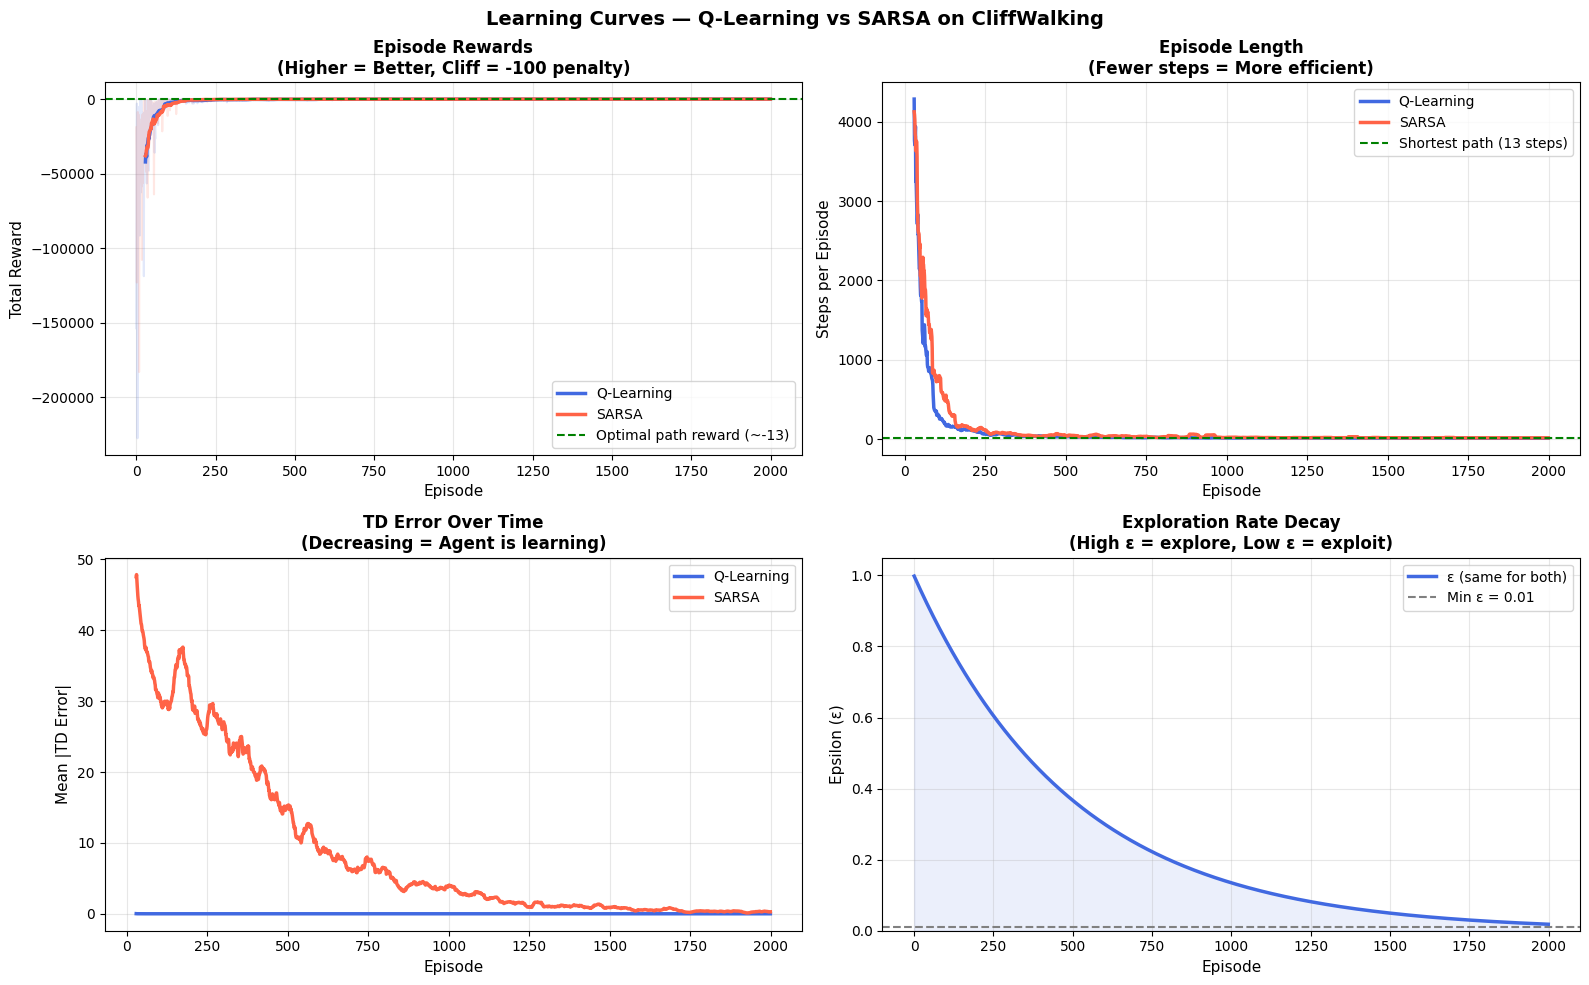

📊 Saved: learning_curves.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def smooth(data, window=20):
    """Moving average for smoother curves"""
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 1. Episode Rewards ────────────────────────────────────────────────────────
ax = axes[0, 0]
episodes = range(len(ql_history['rewards']))
ax.plot(episodes, ql_history['rewards'],  alpha=0.15, color='royalblue')
ax.plot(episodes, sarsa_history['rewards'], alpha=0.15, color='tomato')
w = 30
ax.plot(range(w-1, len(ql_history['rewards'])),    smooth(ql_history['rewards'], w),
        color='royalblue', lw=2.5, label='Q-Learning')
ax.plot(range(w-1, len(sarsa_history['rewards'])), smooth(sarsa_history['rewards'], w),
        color='tomato',    lw=2.5, label='SARSA')
ax.axhline(-13, color='green', linestyle='--', lw=1.5, label='Optimal path reward (~-13)')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Total Reward', fontsize=11)
ax.set_title('Episode Rewards\n(Higher = Better, Cliff = -100 penalty)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 2. Episode Length ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(range(w-1, len(ql_history['lengths'])),    smooth(ql_history['lengths'], w),
        color='royalblue', lw=2.5, label='Q-Learning')
ax.plot(range(w-1, len(sarsa_history['lengths'])), smooth(sarsa_history['lengths'], w),
        color='tomato',    lw=2.5, label='SARSA')
ax.axhline(13, color='green', linestyle='--', lw=1.5, label='Shortest path (13 steps)')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Steps per Episode', fontsize=11)
ax.set_title('Episode Length\n(Fewer steps = More efficient)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 3. TD Error ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(range(w-1, len(ql_history['td_errors'])),    smooth(ql_history['td_errors'], w),
        color='royalblue', lw=2.5, label='Q-Learning')
ax.plot(range(w-1, len(sarsa_history['td_errors'])), smooth(sarsa_history['td_errors'], w),
        color='tomato',    lw=2.5, label='SARSA')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Mean |TD Error|', fontsize=11)
ax.set_title('TD Error Over Time\n(Decreasing = Agent is learning)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 4. Epsilon Decay ─────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(ql_history['epsilon'], color='royalblue', lw=2.5, label='ε (same for both)')
ax.fill_between(range(len(ql_history['epsilon'])), 0, ql_history['epsilon'],
                alpha=0.1, color='royalblue')
ax.axhline(EPSILON_MIN, color='gray', linestyle='--', lw=1.5, label=f'Min ε = {EPSILON_MIN}')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Epsilon (ε)', fontsize=11)
ax.set_title('Exploration Rate Decay\n(High ε = explore, Low ε = exploit)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.suptitle('Learning Curves — Q-Learning vs SARSA on CliffWalking',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: learning_curves.png")


---
<a id='section10'></a>
## 🗺️ Section 10 — Visualizing the Learned Policies

Now let's see **what each agent actually learned** — the Q-values and the resulting policies on the grid.

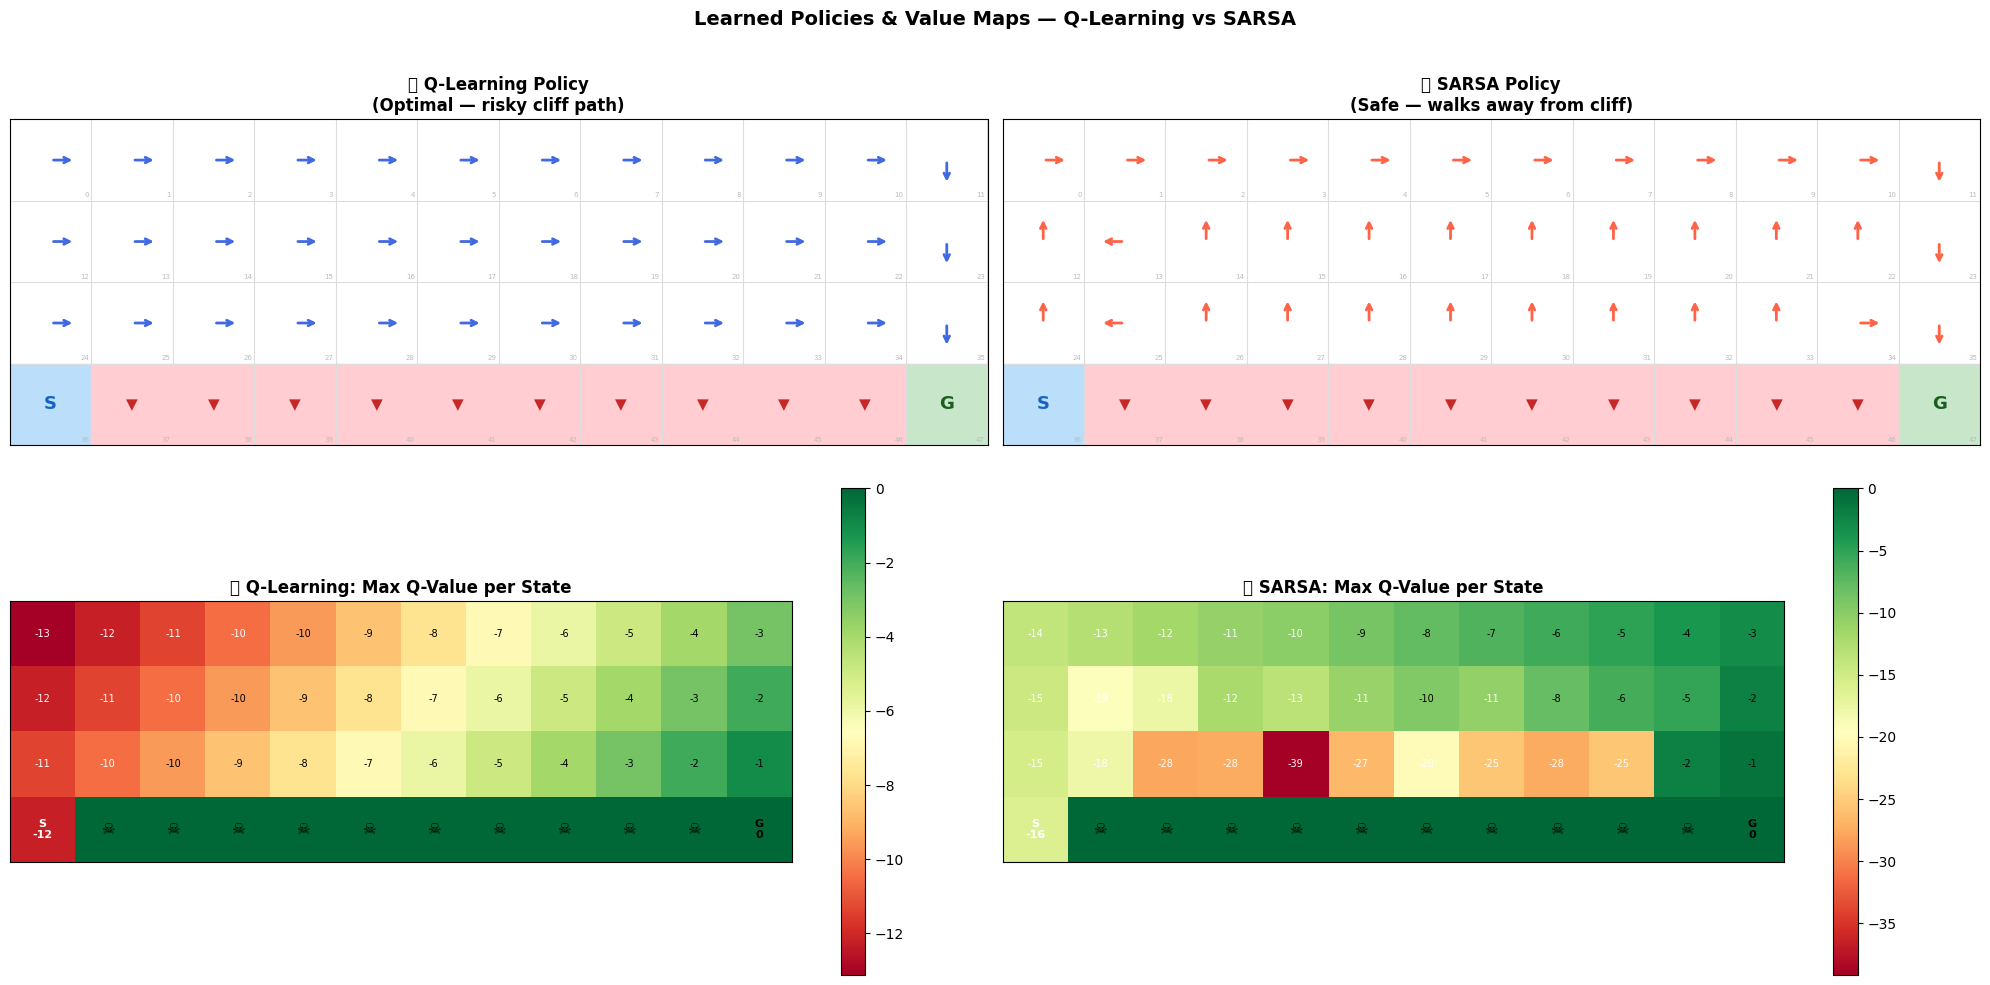

📊 Saved: policies.png

🔍 Observation: Notice how Q-Learning arrows point toward the cliff edge,
   while SARSA arrows stay one row above the cliff — a safer route!


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_policy_grid(Q, title, ax, color):
    """Draw the learned policy as arrows on the CliffWalking grid"""
    policy = np.argmax(Q, axis=1)

    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect('equal')

    dx = {0: 0,    1: 0.3,  2: 0,    3: -0.3}
    dy = {0: -0.3, 1: 0,    2: 0.3,  3: 0}

    for row in range(ROWS):
        for col in range(COLS):
            s = row * COLS + col

            # Background color
            if s == START:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#BBDEFB', zorder=0))
                ax.text(col, row, 'S', ha='center', va='center',
                        fontsize=13, fontweight='bold', color='#1565C0')
            elif s == GOAL:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#C8E6C9', zorder=0))
                ax.text(col, row, 'G', ha='center', va='center',
                        fontsize=13, fontweight='bold', color='#1B5E20')
            elif s in CLIFF:
                ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#FFCDD2', zorder=0))
                ax.text(col, row, '▼', ha='center', va='center',
                        fontsize=11, color='#C62828')
            else:
                a = policy[s]
                ax.annotate('', xy=(col + dx[a], row + dy[a]), xytext=(col, row),
                            arrowprops=dict(arrowstyle='->', color=color, lw=2))

            ax.text(col + 0.47, row + 0.47, str(s), ha='right', va='bottom',
                    fontsize=5, color='#bbb')

    for r in range(ROWS + 1):
        ax.axhline(r - 0.5, color='#ddd', lw=0.8)
    for c in range(COLS + 1):
        ax.axvline(c - 0.5, color='#ddd', lw=0.8)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold')


def plot_value_heatmap(Q, title, ax):
    """Draw the max Q-value per state as a heatmap"""
    V = np.max(Q, axis=1).reshape(ROWS, COLS)
    # Mask cliff
    mask = np.zeros_like(V)
    for s in CLIFF:
        mask[s // COLS, s % COLS] = 1

    im = ax.imshow(V, cmap='RdYlGn', aspect='equal')
    for row in range(ROWS):
        for col in range(COLS):
            s = row * COLS + col
            val = V[row, col]
            if s in CLIFF:
                ax.text(col, row, '☠', ha='center', va='center', fontsize=11)
            elif s == START:
                ax.text(col, row, f'S\n{val:.0f}', ha='center', va='center',
                        fontsize=8, fontweight='bold', color='white')
            elif s == GOAL:
                ax.text(col, row, f'G\n{val:.0f}', ha='center', va='center',
                        fontsize=8, fontweight='bold', color='black')
            else:
                c = 'white' if val < -10 else 'black'
                ax.text(col, row, f'{val:.0f}', ha='center', va='center',
                        fontsize=7, color=c)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold')
    return im


fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Top row: Policies
plot_policy_grid(ql_agent.Q,    '🔵 Q-Learning Policy\n(Optimal — risky cliff path)',    axes[0,0], 'royalblue')
plot_policy_grid(sarsa_agent.Q, '🔴 SARSA Policy\n(Safe — walks away from cliff)', axes[0,1], 'tomato')

# Bottom row: Value heatmaps
im1 = plot_value_heatmap(ql_agent.Q,    '🔵 Q-Learning: Max Q-Value per State', axes[1,0])
im2 = plot_value_heatmap(sarsa_agent.Q, '🔴 SARSA: Max Q-Value per State',       axes[1,1])

plt.colorbar(im1, ax=axes[1,0])
plt.colorbar(im2, ax=axes[1,1])

plt.suptitle('Learned Policies & Value Maps — Q-Learning vs SARSA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('policies.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: policies.png")
print("\n🔍 Observation: Notice how Q-Learning arrows point toward the cliff edge,")
print("   while SARSA arrows stay one row above the cliff — a safer route!")

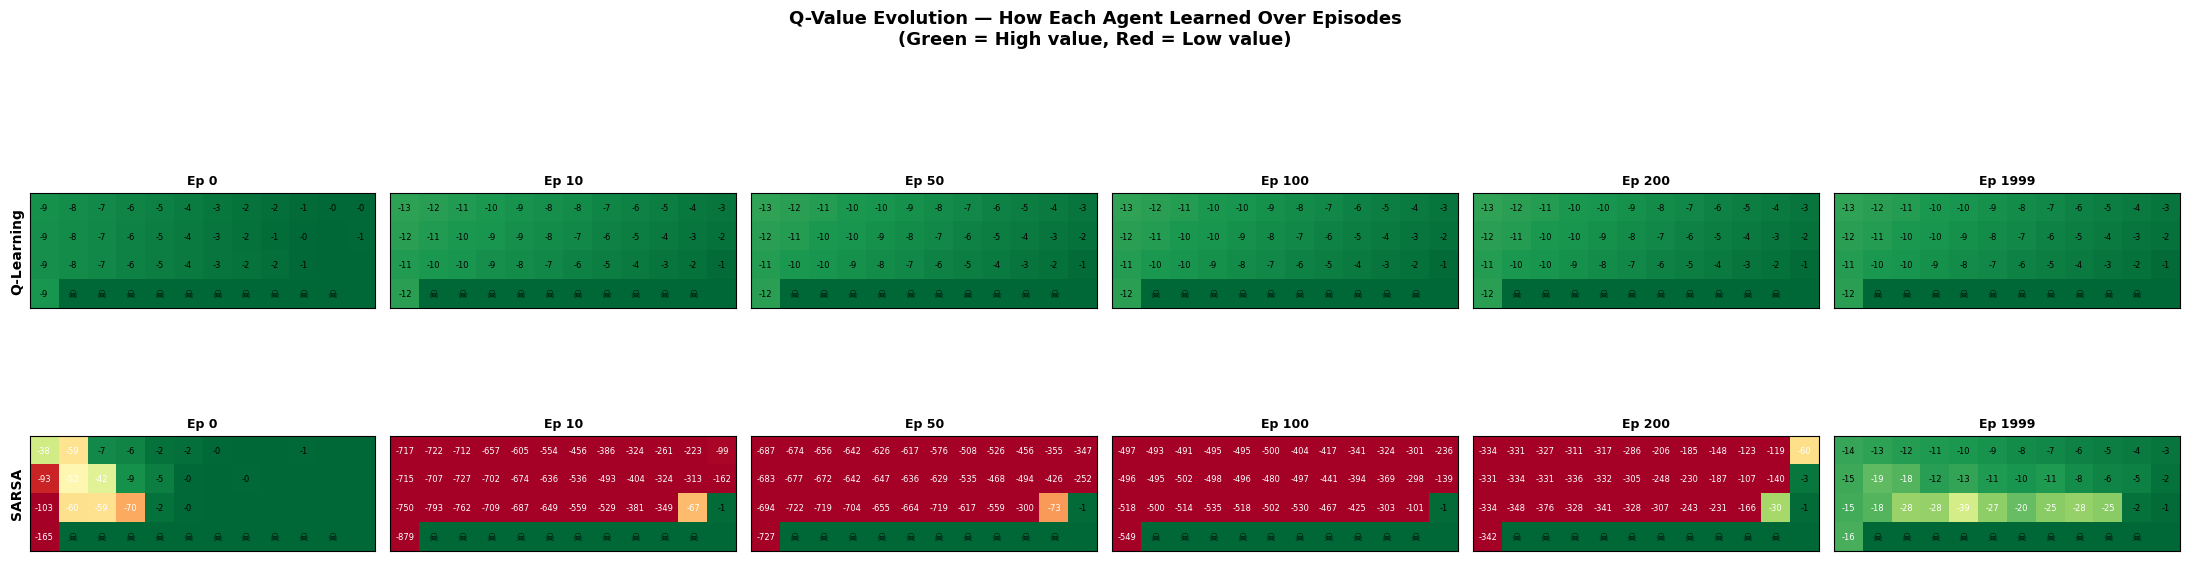

📊 Saved: q_evolution.png


In [9]:
# Q-table evolution: how values changed at key snapshots
fig, axes = plt.subplots(2, len(ql_history['q_snapshots']), figsize=(22, 7))
snap_eps = sorted(ql_history['q_snapshots'].keys())

for col_idx, ep in enumerate(snap_eps):
    for row_idx, (agent_name, q_snaps) in enumerate(
        [('Q-Learning', ql_history['q_snapshots']),
         ('SARSA',      sarsa_history['q_snapshots'])]
    ):
        ax = axes[row_idx, col_idx]
        Q_snap = q_snaps[ep]
        V_snap = np.max(Q_snap, axis=1).reshape(ROWS, COLS)
        im = ax.imshow(V_snap, cmap='RdYlGn', aspect='equal', vmin=-100, vmax=0)
        
        for r in range(ROWS):
            for c in range(COLS):
                s = r * COLS + c
                val = V_snap[r, c]
                if s in CLIFF:
                    ax.text(c, r, '☠', ha='center', va='center', fontsize=8)
                elif val != 0:
                    color = 'white' if val < -15 else 'black'
                    ax.text(c, r, f'{val:.0f}', ha='center', va='center',
                            fontsize=6, color=color)
                            
        ax.set_xticks([]); ax.set_yticks([])
        # تحديد العنوان الفرعي لكل عمود
        ax.set_title(f'Ep {ep}', fontsize=9, fontweight='bold')
        
        if col_idx == 0:
            ax.set_ylabel(agent_name, fontsize=10, fontweight='bold')

# تصحيح السطر الذي كان يسبب الخطأ هنا باستخدام \n
fig.suptitle('Q-Value Evolution — How Each Agent Learned Over Episodes\n(Green = High value, Red = Low value)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: q_evolution.png")

---
<a id='section11'></a>
## 🎬 Section 11 — Watching the Agents Walk (Video)

Now let's animate both agents walking through the CliffWalking environment using their learned policies (greedy — no exploration).

In [10]:
def run_greedy_episode(agent, env):
    """Run one episode with pure greedy policy (no exploration) and collect frames"""
    state, _ = env.reset()
    done   = False
    frames = [env.render()]
    path   = [state]
    total_reward = 0
    steps = 0

    while not done and steps < 200:
        action = np.argmax(agent.Q[state])   # Pure greedy — no epsilon!
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        path.append(state)
        total_reward += reward
        steps += 1

    return frames, path, total_reward, steps


def animate_episode(frames, title, path, total_reward, steps):
    """Create and display an animation from frames"""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    img = ax.imshow(frames[0])

    def update(frame_idx):
        img.set_data(frames[frame_idx])
        step_info = f'Step {frame_idx}/{len(frames)-1}'
        ax.set_title(f'{title}\n{step_info} | Total reward: {total_reward} | Path length: {steps}',
                     fontsize=11, pad=8)
        return [img]

    anim = animation.FuncAnimation(
        fig, update,
        frames=len(frames),
        interval=400,   # ms per frame
        blit=True,
        repeat=True
    )

    plt.tight_layout()
    plt.close()
    return anim


# ── Run greedy episodes ───────────────────────────────────────────────────────
env_render = gym.make('CliffWalking-v1', render_mode='rgb_array')

print("🎬 Running greedy episodes...")
print()

ql_frames, ql_path, ql_reward, ql_steps = run_greedy_episode(ql_agent, env_render)
print(f"🔵 Q-Learning:")
print(f"   Path:   {ql_path}")
print(f"   Steps:  {ql_steps}  |  Total reward: {ql_reward}")
print()

sarsa_frames, sarsa_path, sarsa_reward, sarsa_steps = run_greedy_episode(sarsa_agent, env_render)
print(f"🔴 SARSA:")
print(f"   Path:   {sarsa_path}")
print(f"   Steps:  {sarsa_steps}  |  Total reward: {sarsa_reward}")

env_render.close()

🎬 Running greedy episodes...



error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


🔵 Q-Learning:
   Path:   [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
   Steps:  13  |  Total reward: -13

🔴 SARSA:
   Path:   [36, 24, 12, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 23, 35, 47]
   Steps:  17  |  Total reward: -17


In [11]:
# ── Display Q-Learning animation ─────────────────────────────────────────────
print("🔵 Q-Learning agent walkthrough:")
ql_anim = animate_episode(
    ql_frames,
    title='🔵 Q-Learning — Greedy Policy (No Exploration)',
    path=ql_path,
    total_reward=ql_reward,
    steps=ql_steps
)
HTML(ql_anim.to_jshtml())

🔵 Q-Learning agent walkthrough:


In [12]:
# ── Display SARSA animation ───────────────────────────────────────────────────
print("🔴 SARSA agent walkthrough:")
sarsa_anim = animate_episode(
    sarsa_frames,
    title='🔴 SARSA — Greedy Policy (No Exploration)',
    path=sarsa_path,
    total_reward=sarsa_reward,
    steps=sarsa_steps
)
HTML(sarsa_anim.to_jshtml())

🔴 SARSA agent walkthrough:


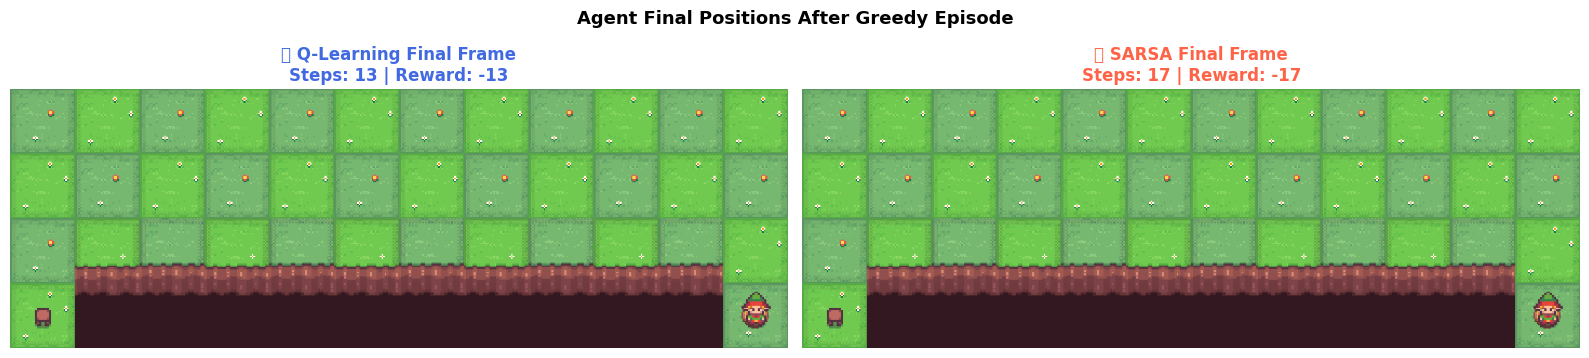

In [13]:
# ── Side-by-side final frame comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].imshow(ql_frames[-1])
axes[0].axis('off')
axes[0].set_title(f'🔵 Q-Learning Final Frame\nSteps: {ql_steps} | Reward: {ql_reward}',
                  fontsize=12, fontweight='bold', color='royalblue')

axes[1].imshow(sarsa_frames[-1])
axes[1].axis('off')
axes[1].set_title(f'🔴 SARSA Final Frame\nSteps: {sarsa_steps} | Reward: {sarsa_reward}',
                  fontsize=12, fontweight='bold', color='tomato')

plt.suptitle('Agent Final Positions After Greedy Episode', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_frames.png', dpi=150, bbox_inches='tight')
plt.show()

---
<a id='section12'></a>
## ⚔️ Section 12 — Head-to-Head Comparison

In [14]:
# ── Numerical comparison ─────────────────────────────────────────────────────
last_n = 50   # Compare over last 50 episodes

ql_avg_r  = np.mean(ql_history['rewards'][-last_n:])
sar_avg_r = np.mean(sarsa_history['rewards'][-last_n:])
ql_avg_l  = np.mean(ql_history['lengths'][-last_n:])
sar_avg_l = np.mean(sarsa_history['lengths'][-last_n:])

print("╔══════════════════════════════════════════════════════════════╗")
print("║           Head-to-Head: Q-Learning vs SARSA                 ║")
print("║               on CliffWalking-v0 (500 episodes)             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Metric':<30} {'Q-Learning':>12}  {'SARSA':>12} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Avg reward (last 50 eps)':<30} {ql_avg_r:>12.1f}  {sar_avg_r:>12.1f} ║")
print(f"║  {'Avg steps  (last 50 eps)':<30} {ql_avg_l:>12.1f}  {sar_avg_l:>12.1f} ║")
print(f"║  {'Greedy episode reward':<30} {ql_reward:>12}  {sarsa_reward:>12} ║")
print(f"║  {'Greedy episode steps':<30} {ql_steps:>12}  {sarsa_steps:>12} ║")
print(f"║  {'Policy type':<30} {'Off-policy':>12}  {'On-policy':>12} ║")
print(f"║  {'Path near cliff?':<30} {'Yes (risky)':>12}  {'No (safe)':>12} ║")
print("╚══════════════════════════════════════════════════════════════╝")
print()
print("📌 Key insight:")
print("   During training (with ε-greedy), Q-Learning earns LOWER rewards")
print("   because it learns the risky optimal policy but sometimes falls off")
print("   due to random exploration near the cliff.")
print()
print("   SARSA earns HIGHER rewards during training because it accounts")
print("   for its own exploration in updates — so it learns to stay safe.")
print()
print("   But in the GREEDY (no exploration) evaluation:")
print("   Q-Learning takes the shorter optimal path!")

╔══════════════════════════════════════════════════════════════╗
║           Head-to-Head: Q-Learning vs SARSA                 ║
║               on CliffWalking-v0 (500 episodes)             ║
╠══════════════════════════════════════════════════════════════╣
║  Metric                           Q-Learning         SARSA ║
╠══════════════════════════════════════════════════════════════╣
║  Avg reward (last 50 eps)              -15.3         -18.2 ║
║  Avg steps  (last 50 eps)               13.3          18.2 ║
║  Greedy episode reward                   -13           -17 ║
║  Greedy episode steps                     13            17 ║
║  Policy type                      Off-policy     On-policy ║
║  Path near cliff?                Yes (risky)     No (safe) ║
╚══════════════════════════════════════════════════════════════╝

📌 Key insight:
   During training (with ε-greedy), Q-Learning earns LOWER rewards
   because it learns the risky optimal policy but sometimes falls off
   due to random e

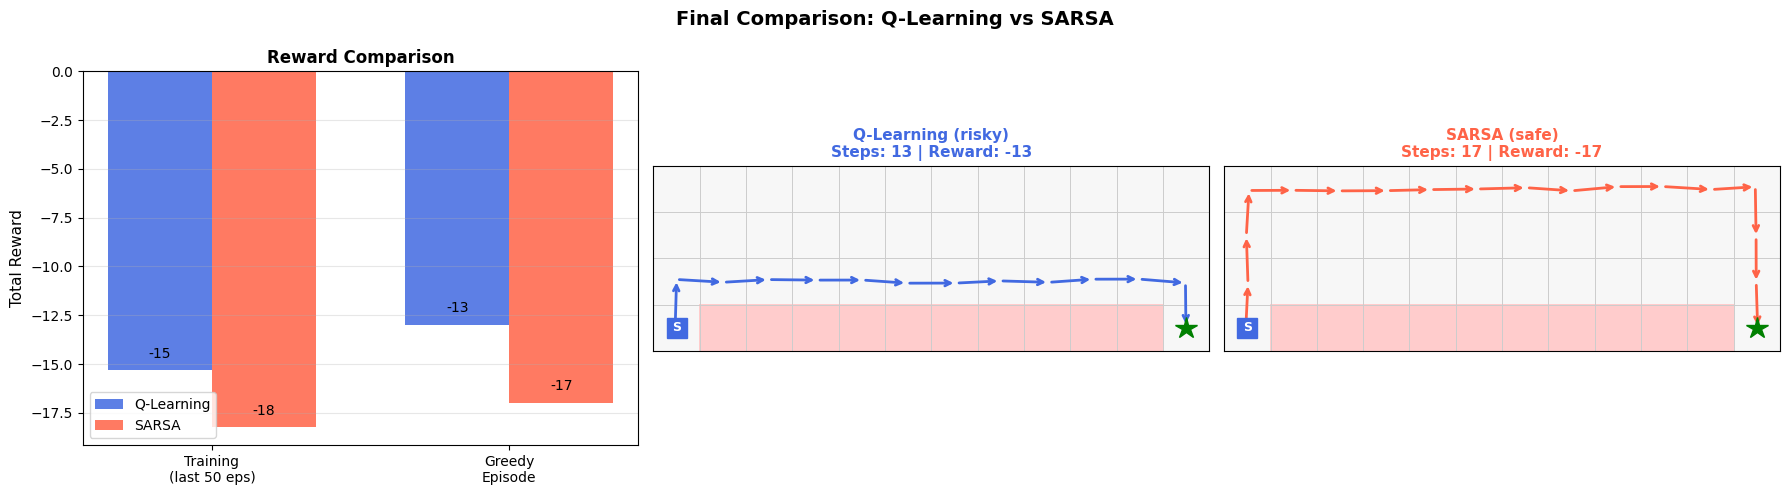

📊 Saved: comparison_summary.png


In [15]:
# ── Visual summary ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Reward comparison bar
ax = axes[0]
categories = [f'Training\n(last {last_n} eps)', 'Greedy\nEpisode']
ql_vals    = [ql_avg_r,  ql_reward]
sarsa_vals = [sar_avg_r, sarsa_reward]

x = np.arange(len(categories))
width = 0.35
bars1 = ax.bar(x - width/2, ql_vals,    width, label='Q-Learning', color='royalblue', alpha=0.85)
bars2 = ax.bar(x + width/2, sarsa_vals, width, label='SARSA',       color='tomato',    alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Total Reward', fontsize=11)
ax.set_title('Reward Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 2. Path visualization on grid
for idx, (agent, path, color, label) in enumerate([
    (ql_agent,    ql_path,    'royalblue', 'Q-Learning (risky)'),
    (sarsa_agent, sarsa_path, 'tomato',    'SARSA (safe)')
]):
    ax = axes[idx + 1]
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect('equal')

    # Grid background
    bg = np.ones((ROWS, COLS, 3)) * 0.97
    for s in CLIFF:
        bg[s//COLS, s%COLS] = [1.0, 0.8, 0.8]
    ax.imshow(bg, aspect='equal', extent=[-0.5, COLS-0.5, ROWS-0.5, -0.5])

    # Draw path
    path_rows = [s // COLS + np.random.uniform(-0.05, 0.05) for s in path]
    path_cols = [s %  COLS + np.random.uniform(-0.05, 0.05) for s in path]
    for i in range(len(path)-1):
        ax.annotate('', xy=(path_cols[i+1], path_rows[i+1]),
                    xytext=(path_cols[i], path_rows[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))

    # Start / Goal markers
    ax.plot(0, 3, 's', ms=14, color='royalblue', zorder=5)
    ax.text(0, 3, 'S', ha='center', va='center', fontsize=9, fontweight='bold', color='white', zorder=6)
    ax.plot(11, 3, '*', ms=16, color='green', zorder=5)

    # Grid lines
    for r in range(ROWS+1): ax.axhline(r-0.5, color='#ccc', lw=0.7)
    for c in range(COLS+1): ax.axvline(c-0.5, color='#ccc', lw=0.7)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{label}\nSteps: {len(path)-1} | Reward: {ql_reward if idx==0 else sarsa_reward}',
                 fontsize=11, fontweight='bold', color=color)

plt.suptitle('Final Comparison: Q-Learning vs SARSA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison_summary.png")

---
<a id='section13'></a>
## 🎓 Section 13 — Key Takeaways & What's Next

### 🔑 Summary

| Concept | Core Idea |
|---|---|
| **Model-Free RL** | Learn from experience — no transition model needed |
| **Q-Function Q(s,a)** | Expected total reward from state s, taking action a, then acting optimally |
| **TD Error** | The surprise signal: how wrong was our prediction? |
| **Q-Learning** | Off-policy: target uses max Q(s',*) — learns optimal regardless of behavior |
| **SARSA** | On-policy: target uses Q(s',a') — learns about the policy being followed |
| **ε-greedy** | Balance exploration (random) and exploitation (greedy) |
| **The Cliff insight** | Q-Learning learns optimal (risky) path; SARSA learns safe path |

### 💡 When to Choose Which?

| Situation | Prefer |
|---|---|
| You want the mathematically optimal policy | Q-Learning |
| Your agent explores near dangerous states | SARSA (safer during learning!) |
| You have a simulator to train in (safely) | Q-Learning |
| Real-world deployment with exploration | SARSA |
| Very large state spaces | Neither — use DQN (next episode!) |

### 🧩 Experiments to Try

1. **Change ε-decay**: Try `epsilon_decay=0.999` (slower decay) — does SARSA become even safer?
2. **Change alpha**: Try `alpha=0.1` (slow learner) vs `alpha=0.9` (fast but unstable)
3. **Change gamma**: Try `gamma=0.5` — does the agent care less about the far-away Goal?
4. **Slippery cliff**: Add noise to actions — does SARSA's advantage grow?
5. **10×10 grid**: Create a custom larger environment

### 🚀 What's Next in the Series?

| Episode | Algorithm | Key Idea |
|---|---|---|
| ✅ 1 | Value Iteration | DP — price every state |
| ✅ 2 | Policy Iteration | DP — evaluate & improve |
| ✅ 3 | Q-Learning & SARSA | Model-free TD learning |
| ▶️ 4 | **Deep Q-Network (DQN)** | Neural net replaces Q-table — scales to millions of states |
| ▶️ 5 | **PPO** | Policy gradient — continuous actions (robotics!) |



*If this notebook helped you, please give it an upvote ⬆️ — it helps others find it. Happy learning! 🙏*